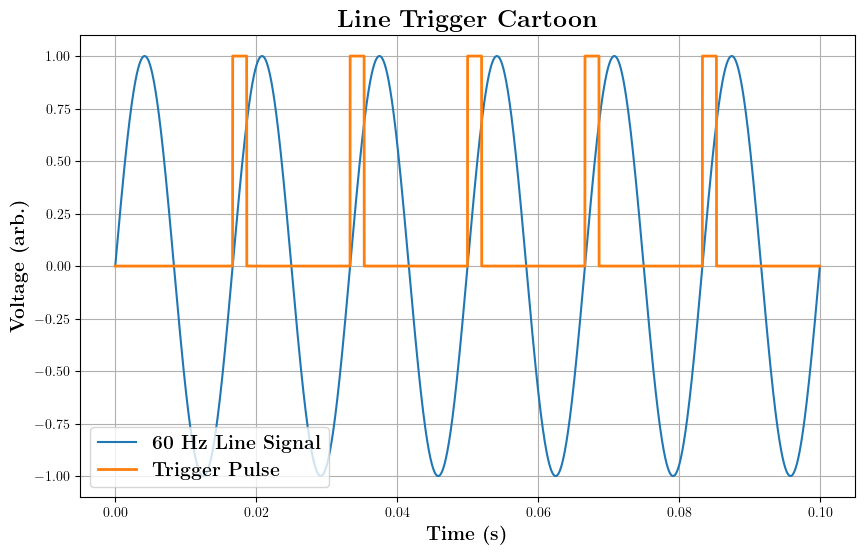

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---------------------------
# LaTeX styling
# ---------------------------
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# -----------------------
# Parameters
# -----------------------
fs = 100000          # sampling frequency (Hz)
duration = 0.1       # seconds
f_line = 60          # line frequency (Hz)
pulse_width = 0.002  # trigger pulse width (seconds)

# -----------------------
# Time axis
# -----------------------
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# -----------------------
# 60 Hz line signal
# -----------------------
line_signal = np.sin(2 * np.pi * f_line * t)

# -----------------------
# Detect rising zero crossings
# -----------------------
zero_crossings = np.where(
    (line_signal[:-1] < 0) & (line_signal[1:] >= 0)
)[0]

# -----------------------
# Generate trigger pulses
# -----------------------
trigger = np.zeros_like(t)
pulse_samples = int(pulse_width * fs)

for idx in zero_crossings:
    trigger[idx:idx + pulse_samples] = 1

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10, 6))

plt.plot(t, line_signal, label=r"\textbf{60 Hz Line Signal}")
plt.plot(t, trigger, label=r"\textbf{Trigger Pulse}", linewidth=2)

plt.xlabel(r"\textbf{Time (s)}", fontsize = 14)
plt.ylabel(r"\textbf{Voltage (arb.)}", fontsize = 14)
plt.title(r"\textbf{Line Trigger Cartoon}", fontsize = 18)
plt.legend(fontsize = 14)
plt.grid(True)

plt.show()


In [19]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

def B_rel_line_mG(t):
    return B_line_mG(t) - B_line_mG(0)

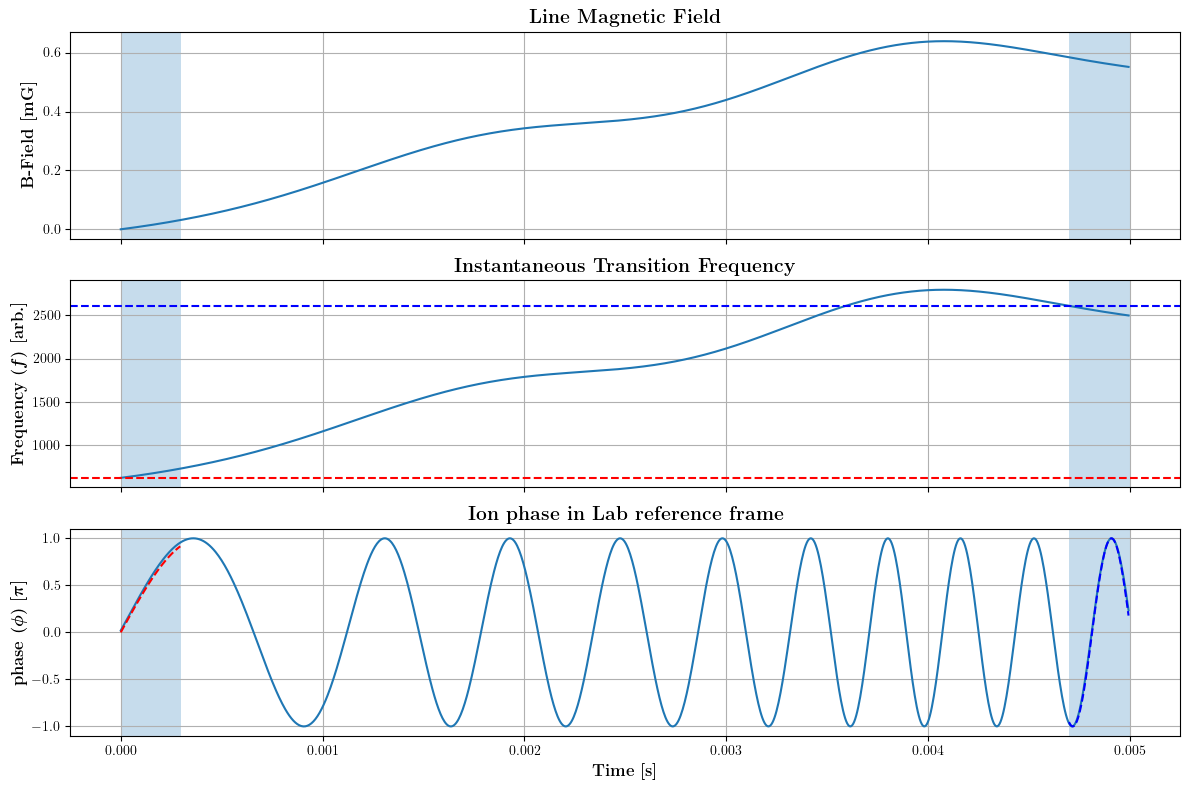

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from matplotlib import rcParams

# ---------------------------
# LaTeX styling
# ---------------------------
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# -----------------------
# Parameters
# -----------------------
fs = 200000
duration = 5000e-6
f0 = 623.3
gamma = 3.4e3
pulse_width = 300e-6

# -----------------------
# Time axis
# -----------------------
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# -----------------------
# Magnetic field
# -----------------------
B_t = B_rel_line_mG(t)
# B_t = 0*np.linspace(0, duration, int(fs * duration), endpoint=False)
# -----------------------
# Detuning
# -----------------------
delta_t = gamma * B_t
f_inst = f0 + delta_t


phase = 2 * np.pi * np.cumsum(f_inst) / fs
signal = np.sin(phase)

# -----------------------
# Ramsey pulse timing
# -----------------------
pulse1_start = 0
pulse1_end = pulse_width

pulse2_start = duration - pulse_width
pulse2_end = duration

# -----------------------
# Oscillator frequencies
# -----------------------
f_LO1 = f_inst[0]                 # frequency at first pulse
f_LO2 = f0 + gamma*B_rel_line_mG(pulse2_start)##f_inst[-1]                # frequency at second pulse

# Create LO signals (only active during pulses)
LO1 = np.zeros_like(t)
LO2 = np.zeros_like(t)
LO_dummy = np.zeros_like(t)
mask1 = (t >= pulse1_start) & (t <= pulse1_end)
mask2 = (t >= pulse2_start) & (t <= pulse2_end)
mask_dummy1 = (t >= pulse1_end) & (t <= pulse2_start)
mask_dummy2 = (t >= 0) & (t <= pulse2_start)

# LO1[mask1] = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
# LO2[mask2] = np.sin(2 * np.pi * f_LO2 * t[mask2] + 0*2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
# LO_dummy[mask_dummy] = np.sin(2 * np.pi * f_LO1 * t[mask_dummy] + 0)

LO1 = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
LO2 = np.sin(2 * np.pi * f_LO2 * t[mask2] + 2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 1*2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
LO_dummy1 = np.sin(2 * np.pi * f_LO1 * t[mask_dummy1] + 0)
LO_dummy2 = np.sin(2 * np.pi * f_LO2 * t[mask_dummy2] + 0)
# -----------------------
# Plot
# -----------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# --- B field ---
axs[0].plot(t, B_t)
axs[0].set_title(r"\textbf{Line Magnetic Field}", fontsize = 14)
axs[0].set_ylabel(r"\textbf{B-Field [mG]}", fontsize = 12)
axs[0].grid(True)

# --- Instantaneous frequency ---
axs[1].plot(t, f_inst)
axs[1].axhline(f_LO1, linestyle='--', color = 'red')
axs[1].axhline(f_LO2, linestyle='--', color = 'blue')
axs[1].set_title(r"\textbf{Instantaneous Transition Frequency}", fontsize = 14)
axs[1].set_ylabel(r"\textbf{Frequency (\boldmath$f$) [arb.]}",  fontsize = 12)
axs[1].grid(True)

# --- Signal + LO ---
axs[2].plot(t, signal, label="Ion (Chirped)")
axs[2].plot(t[mask1], LO1, linestyle='--', label="LO @ first pulse", color = 'red')
axs[2].plot(t[mask2], LO2, linestyle='--', label="LO @ second pulse", color = 'blue')
# axs[2].plot(t[mask_dummy1], LO_dummy1, linestyle='--',  color = 'red', linewidth=0.75)
# axs[2].plot(t[mask_dummy2], LO_dummy2, linestyle='--',  color = 'blue', linewidth=0.75)
axs[2].set_title(r"\textbf{Ion phase in Lab reference frame}", fontsize = 14)
axs[2].set_xlabel(r"\textbf{Time [s]}", fontsize = 12)
axs[2].set_ylabel(r"\textbf{phase (\boldmath$\phi$) [\boldmath$\pi$]}", fontsize = 12)
axs[2].grid(True)
# axs[2].legend()

# Shaded pulse regions
for ax in axs:
    ax.axvspan(pulse1_start, pulse1_end, alpha=0.25)
    ax.axvspan(pulse2_start, pulse2_end, alpha=0.25)

plt.tight_layout()
plt.show()
